In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Loading NorthStar dataset...")

hubs = pd.read_csv("hubs.csv")
customers = pd.read_csv("customers.csv")
drivers = pd.read_csv("drivers.csv")
vehicles = pd.read_csv("vehicles.csv")
orders = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")
incidents = pd.read_csv("incidents.csv")
complaints = pd.read_csv("complaints.csv")
app_events = pd.read_csv("app_events.csv")

print("All files loaded successfully")

Loading NorthStar dataset...
All files loaded successfully


In [3]:
print("Unique pickup zones before cleaning:")
print(sorted(orders["pickup_zone"].dropna().unique()))

zone_fix = {
    "CENTRAL": "Central",
    "Ctr": "Central",
    "NORTH": "North",
    "north": "North",
    "SOUTH": "South",
    "south": "South",
    "EAST": "East",
    "east": "East",
    "WEST": "West",
    "west": "West",
    "AIRPORT": "Airport",
    "RiverSide": "Riverside",
    "RIVERSIDE": "Riverside"
}

orders["pickup_zone"] = orders["pickup_zone"].replace(zone_fix)
orders["dropoff_zone"] = orders["dropoff_zone"].replace(zone_fix)
drivers["base_zone"] = drivers["base_zone"].replace(zone_fix)
vehicles["assigned_zone"] = vehicles["assigned_zone"].replace(zone_fix)

print("Unique pickup zones after cleaning:")
print(sorted(orders["pickup_zone"].dropna().unique()))

Unique pickup zones before cleaning:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']
Unique pickup zones after cleaning:
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [4]:
deliveries["customer_rating_post_delivery"] = deliveries["customer_rating_post_delivery"].fillna(
    deliveries["customer_rating_post_delivery"].median()
)

drivers["training_score"] = drivers["training_score"].fillna(
    drivers["training_score"].median()
)

customers["loyalty_score"] = customers["loyalty_score"].fillna(
    customers["loyalty_score"].median()
)

vehicles["battery_health_pct"] = vehicles["battery_health_pct"].fillna(
    vehicles["battery_health_pct"].median()
)

complaints["compensation_amount"] = complaints["compensation_amount"].fillna(0)
customers["preferred_channel"] = customers["preferred_channel"].fillna("Unknown")
orders["booking_channel"] = orders["booking_channel"].fillna("Unknown")

print("Remaining missing values:")
for name, df in [
    ("orders", orders),
    ("deliveries", deliveries),
    ("drivers", drivers),
    ("customers", customers),
    ("complaints", complaints),
    ("vehicles", vehicles)
]:
    print(name, ":", df.isnull().sum().sum())

Remaining missing values:
orders : 0
deliveries : 19
drivers : 0
customers : 0
complaints : 0
vehicles : 0


In [5]:
deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"])
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"])
complaints["created_at"] = pd.to_datetime(complaints["created_at"])

print("Date columns converted successfully")

Date columns converted successfully


In [6]:
deliveries["delivery_duration_hrs"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

print("Negative durations:", (deliveries["delivery_duration_hrs"] < 0).sum())

deliveries = deliveries[
    deliveries["delivery_duration_hrs"].isna() |
    (deliveries["delivery_duration_hrs"] >= 0)
]

print("Clean delivery duration statistics:")
print(deliveries["delivery_duration_hrs"].describe().round(2))

Negative durations: 64
Clean delivery duration statistics:
count    867.00
mean      10.32
std        8.46
min        0.02
25%        3.50
50%        7.91
75%       15.53
max       43.46
Name: delivery_duration_hrs, dtype: float64


In [7]:
deliveries["cost_per_km"] = (
    deliveries["fuel_or_charge_cost"] / deliveries["route_distance_km"]
)

print("Cost per km statistics:")
print(deliveries["cost_per_km"].describe().round(3))

median_cpk = deliveries["cost_per_km"].median()
deliveries["high_cost_flag"] = deliveries["cost_per_km"] > (median_cpk * 3)

print("High cost deliveries:", deliveries["high_cost_flag"].sum())

Cost per km statistics:
count    886.000
mean       1.249
std        1.209
min        0.174
25%        0.702
50%        0.948
75%        1.329
max       12.364
Name: cost_per_km, dtype: float64
High cost deliveries: 44


In [8]:
deliveries["is_failed"] = (deliveries["delivery_status"] == "Failed").astype(int)
deliveries["is_delayed"] = (deliveries["delivery_status"] == "Delayed").astype(int)

deliveries["high_override"] = (
    deliveries["manual_route_override_count"] >= 3
).astype(int)

print("Failed deliveries:", deliveries["is_failed"].sum())
print("Delayed deliveries:", deliveries["is_delayed"].sum())
print("Deliveries with 3+ manual route overrides:", deliveries["high_override"].sum())

print("\nFailure rate by override flag:")
print(
    deliveries.groupby("high_override")["is_failed"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "failure_rate", "count": "total_deliveries"})
    .round(3)
)

Failed deliveries: 132
Delayed deliveries: 202
Deliveries with 3+ manual route overrides: 83

Failure rate by override flag:
               failure_rate  total_deliveries
high_override                                
0                     0.148               803
1                     0.157                83


In [9]:
complaint_counts = complaints.groupby("customer_id").size().reset_index(
    name="complaint_count"
)

complaint_counts["repeat_complainer"] = (
    complaint_counts["complaint_count"] >= 2
).astype(int)

print("Repeat complainers:", complaint_counts["repeat_complainer"].sum())
print("Single complaint customers:", (complaint_counts["complaint_count"] == 1).sum())

Repeat complainers: 74
Single complaint customers: 159


In [10]:
merged = deliveries.merge(orders, on="order_id", how="inner")

zone_analysis = merged.groupby("pickup_zone").agg(
    total_deliveries=("delivery_id", "count"),
    failed_deliveries=("is_failed", "sum"),
    delayed_deliveries=("is_delayed", "sum"),
    avg_cost_per_km=("cost_per_km", "mean"),
    avg_overrides=("manual_route_override_count", "mean"),
    avg_rating=("customer_rating_post_delivery", "mean")
).reset_index()

zone_analysis["failure_rate_pct"] = round(
    zone_analysis["failed_deliveries"] / zone_analysis["total_deliveries"] * 100,
    1
)

print(zone_analysis.sort_values("failure_rate_pct", ascending=False))

  pickup_zone  total_deliveries  failed_deliveries  delayed_deliveries  \
1     Central               164                 33                  51   
3       North               128                 22                  21   
4   Riverside               112                 18                  25   
6        West               103                 14                  21   
2        East               145                 19                  31   
0     Airport               106                 12                  31   
5       South               128                 14                  22   

   avg_cost_per_km  avg_overrides  avg_rating  failure_rate_pct  
1         1.277591       1.286585    3.543110              20.1  
3         1.355258       0.718750    3.914219              17.2  
4         1.395174       0.696429    3.840893              16.1  
6         1.235211       0.834951    3.843883              13.6  
2         1.332107       0.765517    3.876483              13.1  
0         0

In [11]:
vehicle_merged = deliveries.merge(vehicles, on="vehicle_id", how="inner")

vehicle_perf = vehicle_merged.groupby("vehicle_type").agg(
    total_deliveries=("delivery_id", "count"),
    failed_deliveries=("is_failed", "sum"),
    avg_battery_health=("battery_health_pct", "mean")
).reset_index()

vehicle_perf["failure_rate_pct"] = round(
    vehicle_perf["failed_deliveries"] / vehicle_perf["total_deliveries"] * 100,
    1
)

print(vehicle_perf.sort_values("failure_rate_pct", ascending=False))

  vehicle_type  total_deliveries  failed_deliveries  avg_battery_health  \
1       Diesel               135                 26           71.440000   
0     CargoVan               209                 38           71.987560   
3       Hybrid               226                 38           78.144469   
2           EV               316                 30           81.958544   

   failure_rate_pct  
1              19.3  
0              18.2  
3              16.8  
2               9.5  


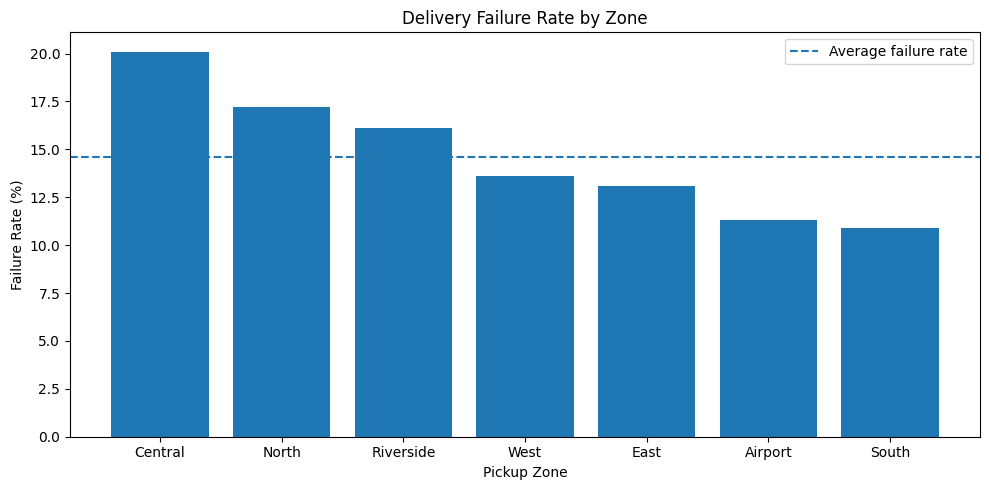

In [12]:
zone_plot = zone_analysis.sort_values("failure_rate_pct", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(zone_plot["pickup_zone"], zone_plot["failure_rate_pct"])
plt.axhline(
    y=zone_analysis["failure_rate_pct"].mean(),
    linestyle="--",
    label="Average failure rate"
)

plt.title("Delivery Failure Rate by Zone")
plt.xlabel("Pickup Zone")
plt.ylabel("Failure Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

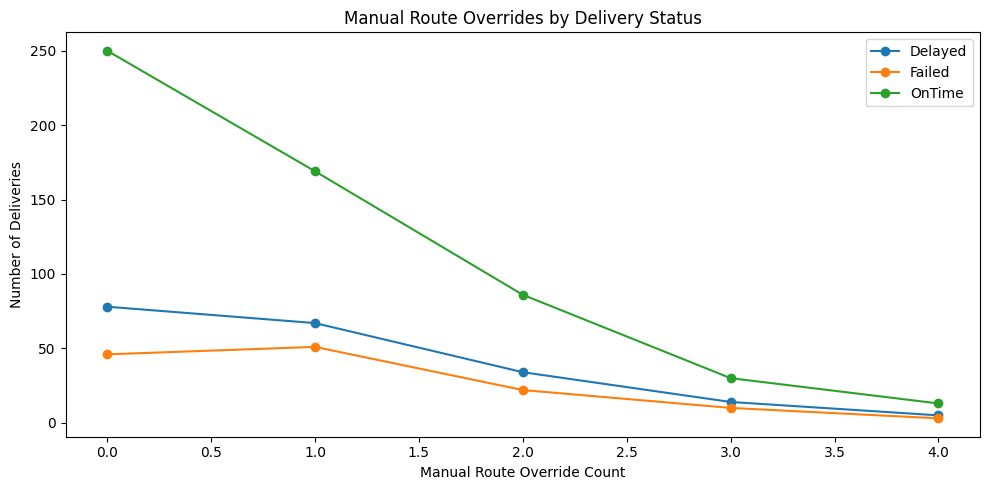

In [13]:
override_status = merged.groupby(
    ["manual_route_override_count", "delivery_status"]
).size().reset_index(name="count")

override_status = override_status[
    override_status["manual_route_override_count"] <= 4
]

statuses = override_status["delivery_status"].unique()

plt.figure(figsize=(10, 5))

for status in statuses:
    subset = override_status[override_status["delivery_status"] == status]
    plt.plot(
        subset["manual_route_override_count"],
        subset["count"],
        marker="o",
        label=status
    )

plt.title("Manual Route Overrides by Delivery Status")
plt.xlabel("Manual Route Override Count")
plt.ylabel("Number of Deliveries")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

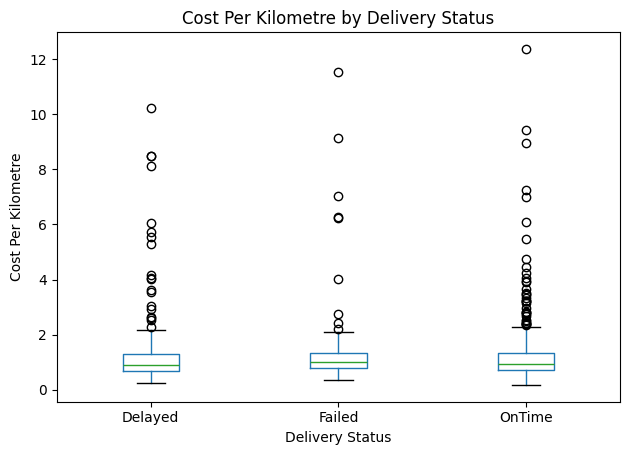

In [14]:
cost_data = deliveries[
    deliveries["delivery_status"].isin(["OnTime", "Delayed", "Failed"])
]

plt.figure(figsize=(8, 5))

cost_data.boxplot(
    column="cost_per_km",
    by="delivery_status",
    grid=False
)

plt.title("Cost Per Kilometre by Delivery Status")
plt.suptitle("")
plt.xlabel("Delivery Status")
plt.ylabel("Cost Per Kilometre")
plt.tight_layout()
plt.show()